# Drift Chamber Geant4 Sim Data Analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits import mplot3d
import pandas as pd
import random
from matplotlib.lines import Line2D

#%matplotlib widget

## Import Data

In [4]:
# Get gas hit data
events_df = pd.read_csv(f'csv/hits/event_action_data.csv')
events_df['energies_'] = events_df['energies'].str.split('|')
events_df['hitx_'] = events_df['hitx'].str.split('|')
events_df['hity_'] = events_df['hity'].str.split('|')
events_df['hitz_'] = events_df['hitz'].str.split('|')
events_df = events_df.drop(columns=['energies', 'hitx', 'hity', 'hitz'])

# Get initial step data
steps_df = pd.read_csv(f'csv/hits/init_step_data.csv')

# Get multiple scattering data
eepos_df = pd.read_csv(f'csv/hits/entry_exit_data.csv')

## Energy loss

In [6]:
def data_for_cylinder(r_outer, r_inner, res, height):
    theta = np.linspace(0, 2 * np.pi, res)
    z = np.linspace(-height, height, res)
    theta_grid, z_grid = np.meshgrid(theta, z)
    
    x_grid = r_outer * np.cos(theta_grid)
    y_grid = r_outer * np.sin(theta_grid)
    
    return x_grid, y_grid, z_grid

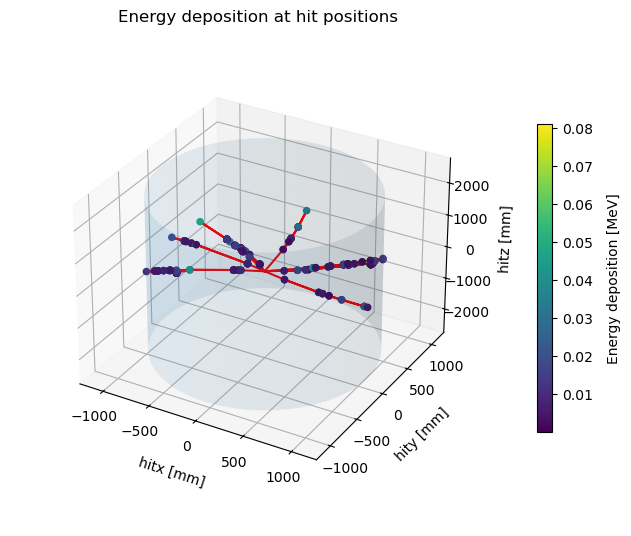

In [7]:
def plot_Edep_per_hit(df, num):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(None, zoom=0.85)
    
    hitx = []
    hity = []
    hitz = []
    energies = []
    
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)
    
    for i in range(0, num):
        cur_row = df.loc[i]
    
        try:
            energies += [float(x) for x in cur_row['energies_'][:-1]]
            x = [float(x) for x in cur_row['hitx_'][:-1]]
            y = [float(y) for y in cur_row['hity_'][:-1]]
            z = [float(z) for z in cur_row['hitz_'][:-1]]

        except:
            continue
    
        ax.plot3D([0.]+x, [0.]+y, [0.]+z, 'red')
    
        hitx += x
        hity += y
        hitz += z
    
    img = ax.scatter(hitx, hity, hitz, c=energies, cmap='viridis', alpha=1.0)
    
    cbar = fig.colorbar(img, ax=ax, shrink=0.5, pad=0.05)
    cbar.set_label("Energy deposition [MeV]", labelpad=10)
    
    plt.title("Energy deposition at hit positions")
    ax.set_xlabel('hitx [mm]', labelpad=10)
    ax.set_ylabel('hity [mm]', labelpad=10)
    ax.set_zlabel('hitz [mm]', labelpad=10)


num_to_plot = 10
plot_Edep_per_hit(events_df, num_to_plot)

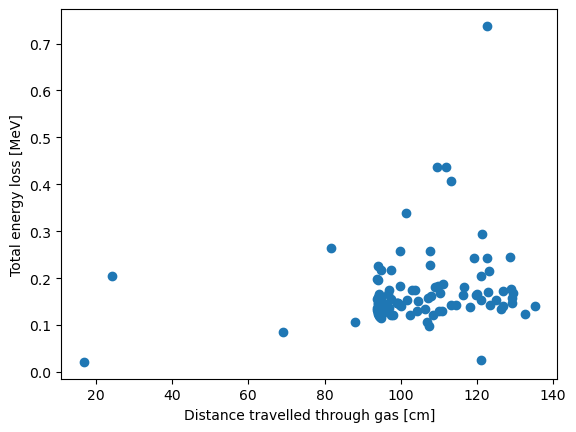

In [8]:
def plot_Eloss_over_dist(df1, df2):
    totE = []
    dist = []
    
    count = 0
    
    for i in range(len(events_df)):
        cur_event = df1.loc[i]
        cur_step = df2.loc[count]
    
        if not cur_event["num_hits"]: continue
        
        totE.append(sum([float(x) for x in cur_event['energies_'][:-1]])) 
        dist.append(cur_step["tot_dist"])
        count += 1
    
    totE = np.array(totE)
    tot_dis = np.array(dist) * 0.1
    
    plt.scatter(tot_dis, totE)
    plt.xlabel("Distance travelled through gas [cm]")
    plt.ylabel("Total energy loss [MeV]")

    return tot_dis

tot_dis = plot_Eloss_over_dist(events_df, steps_df)

'\nfig2 = plt.figure(figsize=(7,5))\nplt.scatter(steps_df["beta_gamma"], steps_df["dEdx"] / density)\nplt.xlabel("βγ")\nplt.ylabel("dE/dx [MeV mm$^2$/g]")\n#'

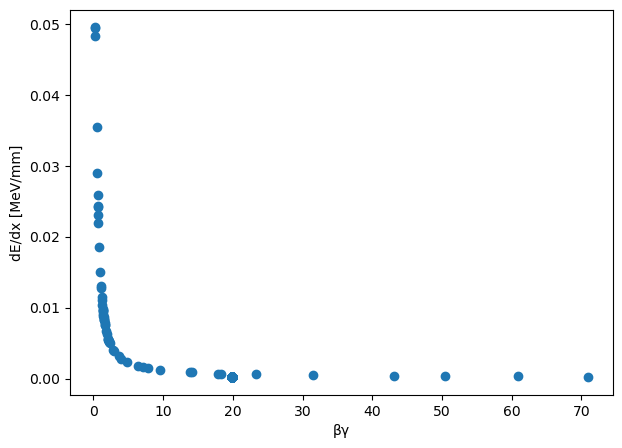

In [74]:
rest_mass = 105.6583715 #MeV
density =  4.75079e15 * 0.000001 #g /mm3

fig = plt.figure(figsize=(7,5))
plt.scatter(steps_df["beta_gamma"], steps_df["dEdx"])
plt.xlabel("βγ")
plt.ylabel("dE/dx [MeV/mm]")

'''
fig2 = plt.figure(figsize=(7,5))
plt.scatter(steps_df["beta_gamma"], steps_df["dEdx"] / density)
plt.xlabel("βγ")
plt.ylabel("dE/dx [MeV mm$^2$/g]")
#'''

## Tracks and Multiple Scattering

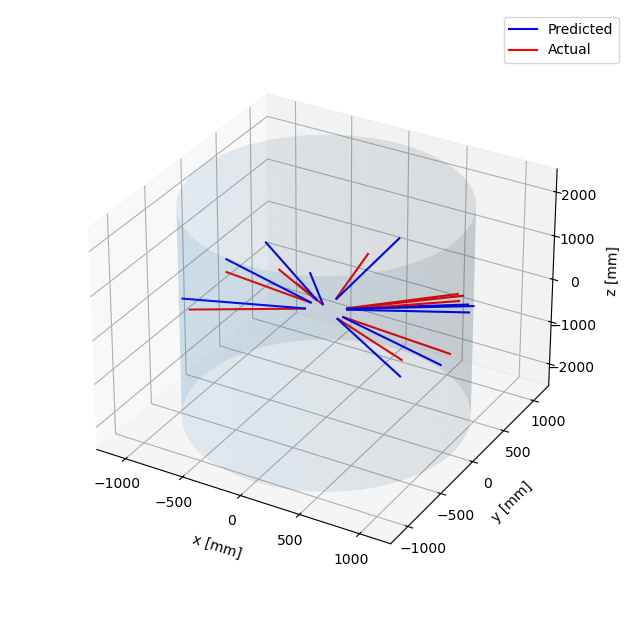

In [11]:
def plot_act_and_pred(df, n):
    '''Plot a linear version of the first n tracks using their start and end points'''
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(None, zoom=0.85)
    
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)
    
    for i in range(0, n):
        curdf = df.loc[i]
    
        ax.plot3D([curdf["actx_ent"], curdf["actx_exit"]], \
                  [curdf["acty_ent"], curdf["acty_exit"]], \
                  [curdf["actz_ent"], curdf["actz_exit"]], 'red')

        ax.plot3D([curdf["predx_ent"], curdf["predx_exit"]], \
                      [curdf["predy_ent"], curdf["predy_exit"]], \
                      [curdf["predz_ent"], curdf["predz_exit"]], 'blue')
    
    ax.set_xlabel('x [mm]', labelpad=10)
    ax.set_ylabel('y [mm]', labelpad=10)
    ax.set_zlabel('z [mm]', labelpad=10)

    # Add legend
    blue_line = Line2D([1, 4], [2, 5], color='blue', label="Predicted")
    red_line = Line2D([1, 4], [2, 5], color='red', label="Actual")
    plt.legend(handles=[blue_line, red_line])
    
num_to_plot = 10
plot_act_and_pred(eepos_df, num_to_plot)

In [12]:
def get_avg_scattering(df):
    sum_dist = 0
    
    for i in range(0, len(df)):
        curdf = df.loc[i]
        sum_dist += np.sqrt( (curdf["actx_ent"]-curdf["predx_ent"])**2 +\
                             (curdf["acty_ent"]-curdf["predy_ent"])**2 +\
                             (curdf["actz_ent"]-curdf["predz_ent"])**2 )

    sum_dist /= len(df)
    
    print(f'Average distance of scattering = {sum_dist:.4f} mm')
    return sum_dist

get_avg_scattering(eepos_df)

Average distance of scattering = 108.1817 mm


108.1817316939897

In [13]:
def plot_outliers(tot_dis):
    '''Plot tracks with shortest distances'''
    
    small_x, small_y, small_z = [], [], []
    
    for i in range(len(tot_dis)):
        cur_event = events_df.loc[i]
        if not cur_event["num_hits"]: continue
        
        if tot_dis[i] < 80:
            small_x.append([float(x) for x in cur_event['hitx_'][:-1]])
            small_y.append([float(y) for y in cur_event['hity_'][:-1]])
            small_z.append([float(z) for z in cur_event['hitz_'][:-1]])
    
    fig = plt.figure(figsize=(8,10))
    ax = fig.add_subplot(projection='3d')
        
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)
    
    for i in range(len(small_x)):
        ax.plot3D([0.]+small_x[i], [0.]+small_y[i], [0.]+small_z[i], 'blue')
        ax.scatter(small_x[i], small_y[i], small_z[i], alpha=1.0, color="blue")
    
    ax.set_xlabel('x [mm]', labelpad=10)
    ax.set_ylabel('y [mm]', labelpad=10)
    ax.set_zlabel('z [mm]', labelpad=10)
    ax.set_title("Tracks of shortest distances")

#plot_outliers(tot_dis)